In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import time

In [ ]:
import astropy.units as u
import astropy.cosmology.units as cu
import astropy.constants as const

In [2]:
import raytrace

In [3]:
rng = np.random.default_rng()

<KeysViewHDF5 ['halo_11069985', 'halo_12925051', 'halo_15386300', 'halo_18373384', 'halo_2069291', 'halo_252455', 'halo_4152102', 'halo_4356618', 'halo_5160064']>


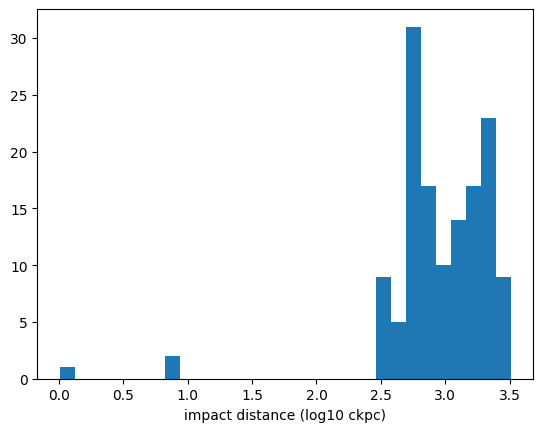

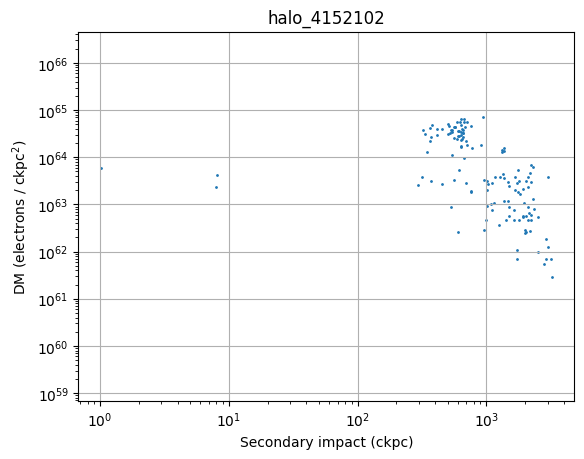

In [16]:
with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    print(f.keys())
    halo_id = 'halo_4152102'
    halo = f[halo_id]
    trace = halo['trace']
    impact = trace['subhalo_impact'][:, 1]

    impact_mag = np.sqrt(raytrace.norm2(impact))
    dm = np.sum(trace['dm_voronoi'][:], axis=1)
    plt.hist(np.log10(impact_mag[impact_mag > 0.01]), bins=30)
    plt.xlabel('impact distance (log10 ckpc)')
    plt.show()
    plt.title(halo_id)
    plt.scatter(impact_mag, dm, s=1)
    plt.xlabel('Secondary impact (ckpc)')
    plt.gca().set_xscale('log')
    plt.gca().set_yscale('log')
    plt.ylabel('DM (electrons / ckpc$^2$)')
    plt.grid()
    plt.show()

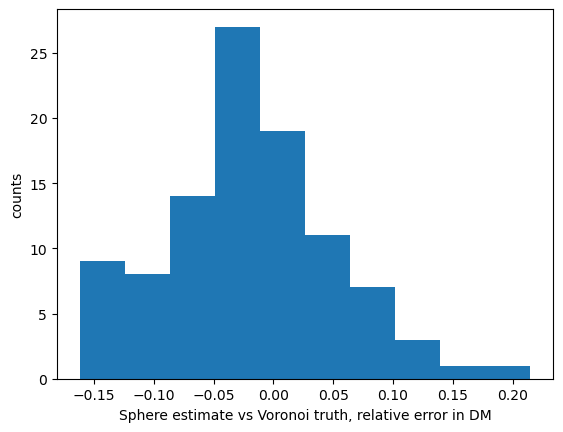

In [108]:
with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    plt.hist(np.array(f[group_id]['DMSphere'])/np.array(f[group_id]['DM']) - 1)
    plt.xlabel('Sphere estimate vs Voronoi truth, relative error in DM')
    plt.ylabel('counts')

In [66]:
import importlib
importlib.reload(raytrace)

<module 'raytrace' from '/home/xingyzt/Documents/halo/raytrace.py'>